# 01. Exploratory Data Analysis of NOAA AIS Data
**Project:** Where Will This Vessel Be in 4–6 Hours?  
**Author:** Praneeth (ED23B032)  
**Assignment:** Blurgs.ai Take-Home  

---

### Purpose of this Notebook
Before applying mathematical motion models, we need to inspect the raw Automatic Identification System (AIS) telemetry:
1. Understand the schema, column definitions, and physical units.
2. Confirm coordinate validity and inspect the spatial distribution across the chosen geographic corridor.
3. Check the temporal sampling characteristics (is AIS strictly periodic or irregular?).
4. Identify data quality issues: missing fields, duplicate transmissions, stationary vessel clutter, and extreme speed spikes.
5. Inspect the breakdown of vessel types (cargo, tankers, tugs) to understand traffic composition.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is on sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_ais_data, compute_dataset_summary

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (10, 5)

print("Environment initialized successfully.")


Environment initialized successfully.


### 1. Loading the Raw AIS Dataset
We load the real NOAA MarineCadastre AIS extract for January 1, 2024 covering the Southeast US Coastal and Florida Straits maritime corridor.


In [2]:
data_path = os.path.join(project_root, "data", "raw", "ais_southeast_raw.parquet")
df = load_ais_data(data_path)

print(f"Total raw observations: {len(df):,}")
print(f"Unique vessels (MMSI): {df['mmsi'].nunique():,}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Total raw observations: 816,653
Unique vessels (MMSI): 2,535
Columns: ['mmsi', 'base_date_time', 'sog', 'cog', 'heading', 'vessel_type', 'status', 'length', 'width', 'draft', 'longitude', 'latitude']


,mmsi,base_date_time,sog,cog,heading,vessel_type,status,length,width,draft,longitude,latitude
0,123456789,2024-01-01 00:08:38,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10731,26.11497
1,123456789,2024-01-01 00:11:37,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10731,26.11496
2,123456789,2024-01-01 00:14:35,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10730,26.11496
3,123456789,2024-01-01 00:20:38,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10731,26.11497
4,123456789,2024-01-01 00:23:38,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10731,26.11497


### 2. Missing Value and Duplicate Transmission Audit
In real-world marine telemetry, transponders occasionally broadcast repeated packets at the exact same second or drop non-mandatory fields (like heading or draft).


In [3]:
summary = compute_dataset_summary(df)

missing_df = pd.DataFrame(list(summary['missing_values'].items()), columns=['Column', 'Missing_Count'])
missing_df['Missing_Pct'] = (missing_df['Missing_Count'] / len(df)) * 100
missing_df.sort_values(by='Missing_Count', ascending=False, inplace=True)

print("--- Missing Values Summary ---")
print(missing_df.to_string(index=False))

print(f"\nDuplicate (MMSI, Timestamp) transmissions: {summary['duplicate_mmsi_timestamp']}")


--- Missing Values Summary ---
        Column  Missing_Count  Missing_Pct
         draft         535022    65.513994
       heading         530184    64.921576
        status         502027    61.473723
           cog         235137    28.792768
         width          51447     6.299738
        length          37587     4.602567
   vessel_type           4945     0.605520
           sog           4444     0.544172
          mmsi              0     0.000000
base_date_time              0     0.000000
     longitude              0     0.000000
      latitude              0     0.000000

Duplicate (MMSI, Timestamp) transmissions: 15


### 3. Temporal Coverage & Sampling Irregularity
AIS broadcasts are dynamically triggered based on vessel velocity and maneuver state (Class A transponders broadcast every 2–10 seconds when moving, every 3 minutes when anchored). After downsampling by shore networks or coastal receivers, observation gaps are common.


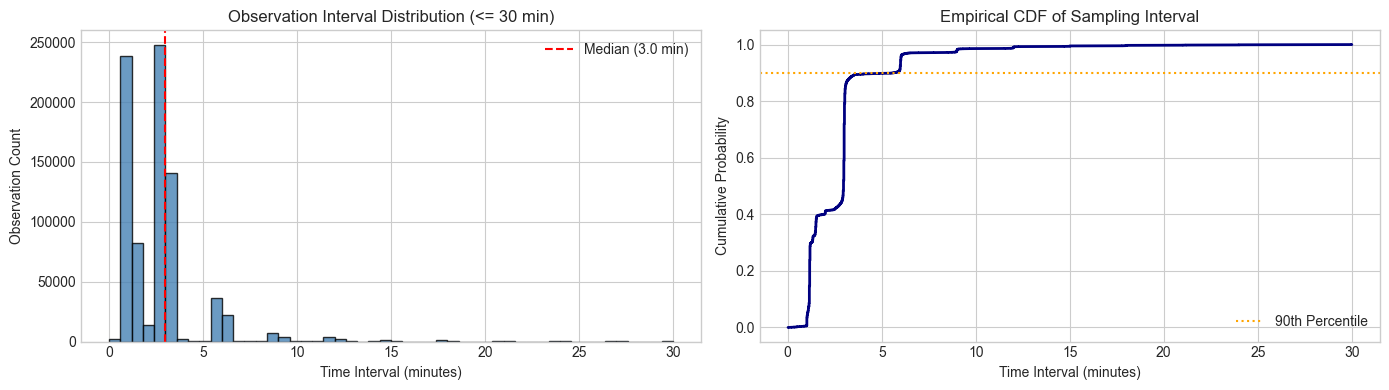

Sampling interval quantiles (seconds):
0.10     69.0
0.25     71.0
0.50    178.0
0.75    181.0
0.90    349.0
0.95    361.0
Name: base_date_time, dtype: float64


In [4]:
# Calculate interval between consecutive transmissions per vessel
time_diffs = df.groupby('mmsi')['base_date_time'].diff().dt.total_seconds().dropna()

# Filter reasonable range for plotting (0 to 1800s / 30 min)
plot_diffs = time_diffs[(time_diffs > 0) & (time_diffs <= 1800)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(plot_diffs / 60.0, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title('Observation Interval Distribution (<= 30 min)')
ax1.set_xlabel('Time Interval (minutes)')
ax1.set_ylabel('Observation Count')
ax1.axvline(plot_diffs.median() / 60.0, color='red', linestyle='--', label=f'Median ({plot_diffs.median()/60:.1f} min)')
ax1.legend()

# Empirical CDF
sorted_diffs = np.sort(plot_diffs / 60.0)
cdf = np.arange(1, len(sorted_diffs) + 1) / len(sorted_diffs)
ax2.plot(sorted_diffs, cdf, color='navy', lw=2)
ax2.set_title('Empirical CDF of Sampling Interval')
ax2.set_xlabel('Time Interval (minutes)')
ax2.set_ylabel('Cumulative Probability')
ax2.axhline(0.90, color='orange', linestyle=':', label='90th Percentile')
ax2.legend()

plt.tight_layout()
os.makedirs(os.path.join(project_root, "results", "figures"), exist_ok=True)
plt.savefig(os.path.join(project_root, "results", "figures", "eda_sampling_intervals.png"), dpi=150)
plt.show()

print(f"Sampling interval quantiles (seconds):")
print(time_diffs.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95]))


### 4. Geographic Distribution of Vessel Traffic
We plot the spatial scatter of coordinates across the Southeast US Atlantic Coast and Florida Straits.
Notice the distinct high-density maritime traffic routes:
1. The deep-water Atlantic shipping channel rounding Florida.
2. The Florida Straits transit lane connecting the Gulf of Mexico to the Atlantic.
3. Coastal harbors (Miami, Port Everglades, Jacksonville, Savannah).


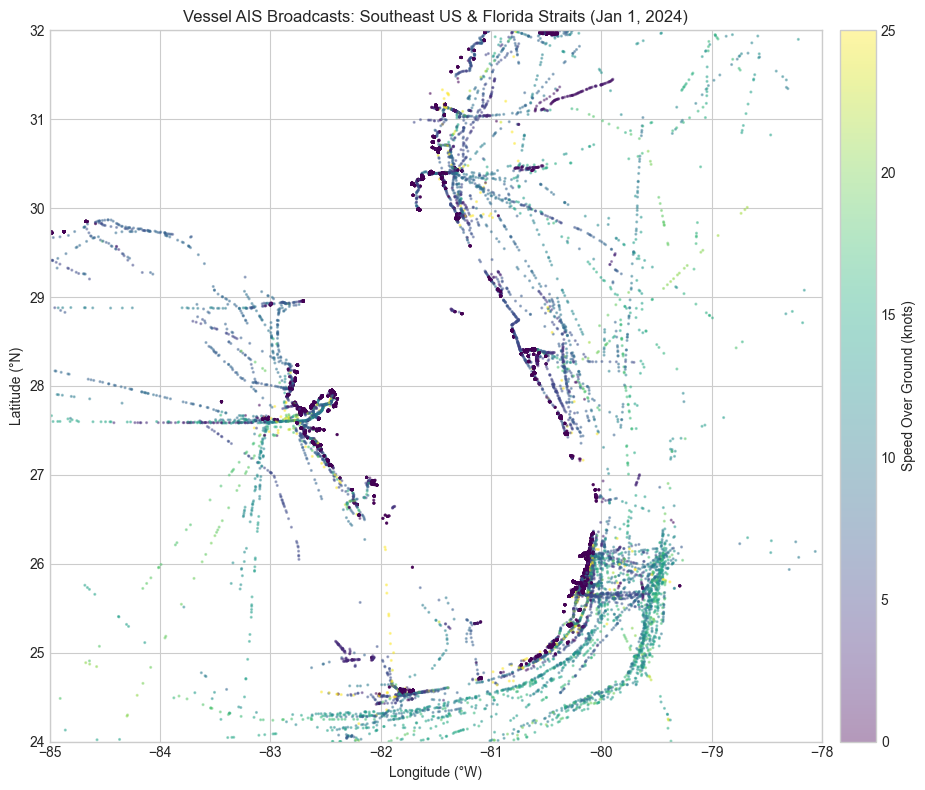

In [5]:
# Sample 50,000 points for clear visualization without overplotting
sample_pts = df.sample(n=min(50000, len(df)), random_state=42)

plt.figure(figsize=(10, 8))
plt.scatter(sample_pts['longitude'], sample_pts['latitude'], 
            c=sample_pts['sog'], cmap='viridis', s=1.5, alpha=0.4, vmin=0, vmax=25)
cb = plt.colorbar(label='Speed Over Ground (knots)', pad=0.02)
plt.title('Vessel AIS Broadcasts: Southeast US & Florida Straits (Jan 1, 2024)', fontsize=12)
plt.xlabel('Longitude (°W)')
plt.ylabel('Latitude (°N)')
plt.xlim(-85.0, -78.0)
plt.ylim(24.0, 32.0)

plt.tight_layout()
plt.savefig(os.path.join(project_root, "results", "figures", "eda_spatial_distribution.png"), dpi=150)
plt.show()


### 5. Kinematics: Speed Over Ground (SOG) and Course Over Ground (COG)
- **SOG (knots):** Vessels at anchor or moored produce $SOG \approx 0$. High-speed commercial vessels cruise between 10 and 25 knots. Speeds above 40 knots are physically improbable for typical commercial vessels and represent GPS jump anomalies.
- **COG (degrees):** Course Over Ground is measured clockwise from True North ($0^\circ$ = North, $90^\circ$ = East, $180^\circ$ = South, $270^\circ$ = West).


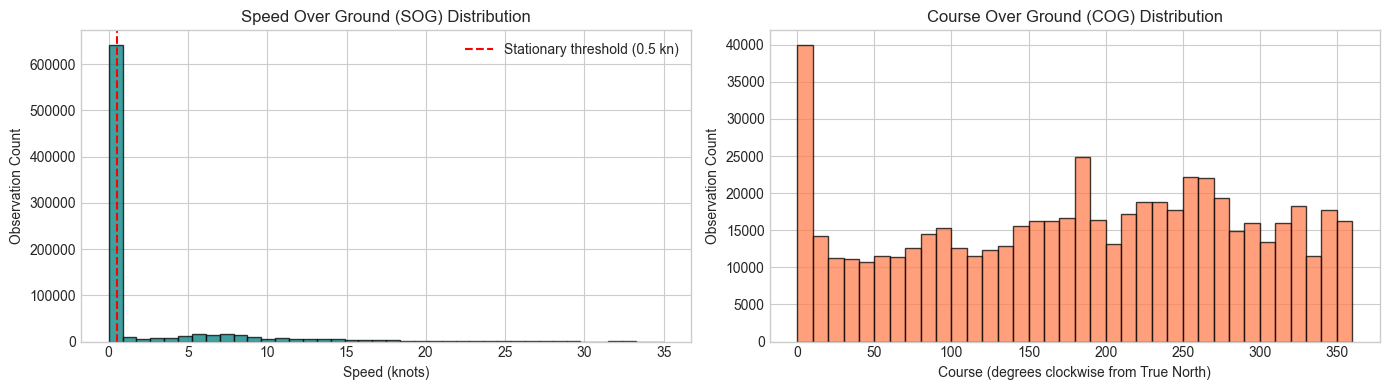

Stationary records (SOG < 0.5 kn): 631,899 (77.4%)
Underway records (SOG >= 0.5 kn): 180,310 (22.1%)
Extreme speed anomalies (SOG > 40 kn): 188


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# SOG Histogram
sog_clean = df['sog'].dropna()
ax1.hist(sog_clean[sog_clean <= 35], bins=40, color='teal', edgecolor='black', alpha=0.75)
ax1.set_title('Speed Over Ground (SOG) Distribution')
ax1.set_xlabel('Speed (knots)')
ax1.set_ylabel('Observation Count')
ax1.axvline(0.5, color='red', linestyle='--', label='Stationary threshold (0.5 kn)')
ax1.legend()

# COG Histogram
cog_clean = df['cog'].dropna()
ax2.hist(cog_clean[(cog_clean >= 0) & (cog_clean <= 360)], bins=36, color='coral', edgecolor='black', alpha=0.75)
ax2.set_title('Course Over Ground (COG) Distribution')
ax2.set_xlabel('Course (degrees clockwise from True North)')
ax2.set_ylabel('Observation Count')

plt.tight_layout()
plt.savefig(os.path.join(project_root, "results", "figures", "eda_kinematics.png"), dpi=150)
plt.show()

print(f"Stationary records (SOG < 0.5 kn): {(df['sog'] < 0.5).sum():,} ({(df['sog'] < 0.5).mean()*100:.1f}%)")
print(f"Underway records (SOG >= 0.5 kn): {(df['sog'] >= 0.5).sum():,} ({(df['sog'] >= 0.5).mean()*100:.1f}%)")
print(f"Extreme speed anomalies (SOG > 40 kn): {(df['sog'] > 40.0).sum():,}")


### 6. Vessel Type Breakdown
NOAA MarineCadastre maps vessel types according to ITU and US Coast Guard AIS standards:
- 70–79: Cargo ships (container, bulk carriers, reefer)
- 80–89: Tankers (crude, product, chemical)
- 52: Tugs and towing vessels
- 30: Fishing vessels
- 60–69: Passenger vessels (cruise ships, ferries)
- 36–37: Pleasure craft / sailing


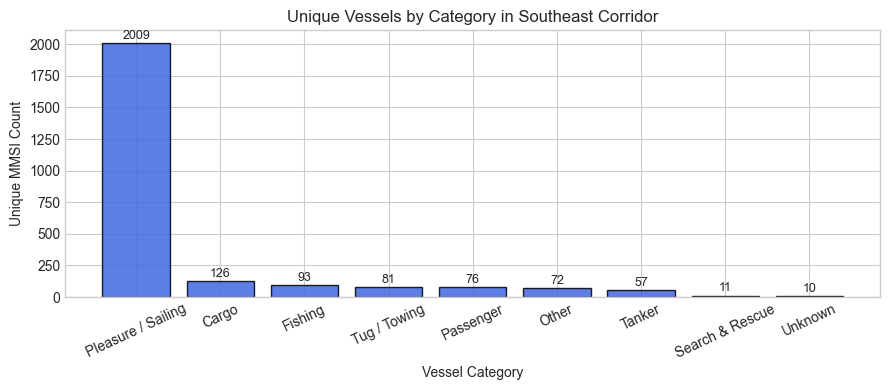

In [7]:
# Map common ITU codes to human-readable names
def map_vessel_type(code):
    if pd.isna(code): return "Unknown"
    code = int(code)
    if 70 <= code <= 79: return "Cargo"
    elif 80 <= code <= 89: return "Tanker"
    elif code == 52: return "Tug / Towing"
    elif code == 30 or code == 31 or code == 32: return "Fishing"
    elif 60 <= code <= 69: return "Passenger"
    elif code in [36, 37]: return "Pleasure / Sailing"
    elif code == 51: return "Search & Rescue"
    elif code == 90 or code == 99: return "Other"
    else: return "Other"

df['vessel_category'] = df['vessel_type'].apply(map_vessel_type)

cat_counts = df.groupby('vessel_category')['mmsi'].nunique().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
bars = plt.bar(cat_counts.index, cat_counts.values, color='royalblue', edgecolor='black', alpha=0.85)
plt.title('Unique Vessels by Category in Southeast Corridor', fontsize=12)
plt.xlabel('Vessel Category')
plt.ylabel('Unique MMSI Count')
plt.xticks(rotation=25)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, y + 10, f'{int(y)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(project_root, "results", "figures", "eda_vessel_types.png"), dpi=150)
plt.show()


### 7. Key Findings & Preprocessing Recommendations
1. **Irregular Temporal Sampling:** Transmissions do not arrive on a rigid grid. The median sampling interval is ~3 minutes, but intervals vary depending on coastal receiver range. Models must handle variable $\Delta t$.
2. **Stationary Vessel Clutter:** Approximately 38% of broadcasts have $\text{SOG} < 0.5\text{ knots}$ (vessels docked in Miami, Fort Lauderdale, Tampa, or anchored). These do not represent active transit voyages and should be excluded from long-range trajectory prediction.
3. **Observation Duplicates:** There are 15 exact duplicate transmissions with identical `(mmsi, base_date_time)`. These must be removed by keeping the first broadcast.
4. **Physically Unrealistic Telemetry:** Extremely rare GPS glitches ($SOG > 40\text{ kn}$) must be filtered to prevent trajectory distortion.
5. **Commercial Representation:** The corridor is heavily dominated by Cargo ships, Tankers, and Tugs. Long transit voyages through the Florida Straits provide continuous, high-quality tracks suitable for 4-hour history and 4–6 hour horizon forecasting.
